ViT logits: (118, 1000)
Neural responses: (118, 39209)
Areas: (39209,)
118 images × 39209 neurons
Explained variance PC1: 0.17425905

Label counts (0=inanimate, 1=animate):
[55 63]


/tmp/ipykernel_261911/4002549582.py:85: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_sig, _ = curve_fit(sigmoid, semantic, y,
/tmp/ipykernel_261911/4002549582.py:95: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_g, _ = curve_fit(gaussian, semantic, y,
/tmp/ipykernel_261911/4002549582.py:67: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-(a * (s - s0) + b)))
/home/maria/global_venv/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T


Found 3 semantic boundary neurons
Neuron 1346  LL(sig)=-59.5  LL(gauss)=-71.7
Neuron 30185  LL(sig)=-40.7  LL(gauss)=-54.3
Neuron 36339  LL(sig)=-23.0  LL(gauss)=-33.7


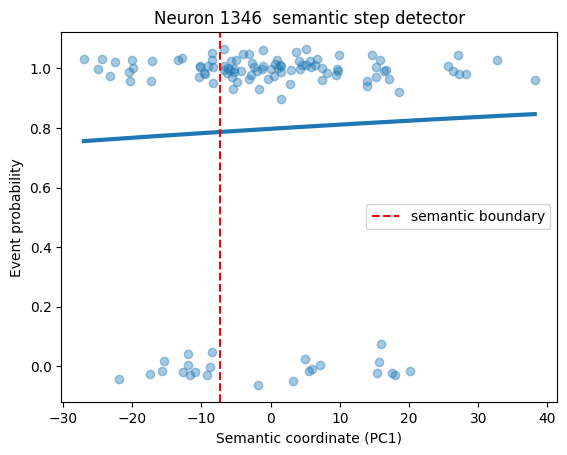

In [2]:
"""
Variance geometry diagnostics for large neural populations
ImageNet-based animate vs inanimate labels

Safe for ~20k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)                  # (neurons,)

print("ViT logits:", vit.shape)
print("Neural responses:", R.shape)
print("Areas:", areas.shape)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================
# ImageNet classes 0–397 = animate, 398–999 = inanimate

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)


# ============================================================
# SEMANTIC AXIS FROM ViT LOGITS
# ============================================================

# standardize logits
vit_z = StandardScaler().fit_transform(vit)

# PCA on logits
pca_vit = PCA(n_components=3)
vit_pca = pca_vit.fit_transform(vit_z)

semantic_axis = vit_pca[:, 0]   # PC1 = animate–inanimate axis (as you found)
print("Explained variance PC1:", pca_vit.explained_variance_ratio_[0])

print("\nLabel counts (0=inanimate, 1=animate):")
print(np.bincount(y))

from scipy.optimize import curve_fit
from scipy.stats import norm

def sigmoid(s, a, s0, b):
    return 1 / (1 + np.exp(-(a * (s - s0) + b)))

def gaussian(s, A, mu, sigma, c):
    return A * np.exp(-(s - mu)**2 / (2 * sigma**2)) + c

def bernoulli_ll(y, p):
    eps = 1e-9
    p = np.clip(p, eps, 1-eps)
    return np.sum(y*np.log(p) + (1-y)*np.log(1-p))

semantic = semantic_axis
boundary_neurons = []

for k in range(R.shape[1]):
    y = (R[:,k] > 0).astype(int)

    # ---- sigmoid fit ----
    try:
        popt_sig, _ = curve_fit(sigmoid, semantic, y,
                                p0=[1.0, np.median(semantic), 0.0],
                                maxfev=5000)
        p_sig = sigmoid(semantic, *popt_sig)
        ll_sig = bernoulli_ll(y, p_sig)
    except:
        continue

    # ---- gaussian fit ----
    try:
        popt_g, _ = curve_fit(gaussian, semantic, y,
                              p0=[1.0, np.mean(semantic), np.std(semantic), 0.1],
                              maxfev=5000)
        p_g = gaussian(semantic, *popt_g)
        p_g = np.clip(p_g, 0, 1)
        ll_g = bernoulli_ll(y, p_g)
    except:
        continue

    if ll_sig - ll_g > 10:   # strong evidence for boundary neuron
        boundary_neurons.append((k, popt_sig, ll_sig, ll_g))

print("Found", len(boundary_neurons), "semantic boundary neurons")

# show first 5
for k, params, ll_s, ll_g in boundary_neurons[:5]:
    print(f"Neuron {k}  LL(sig)={ll_s:.1f}  LL(gauss)={ll_g:.1f}")

k, (a,s0,b),_,_ = boundary_neurons[0]
y = (R[:,k] > 0).astype(int)

sgrid = np.linspace(semantic.min(), semantic.max(), 300)
plt.scatter(semantic, y + 0.03*np.random.randn(len(y)), alpha=0.4)
plt.plot(sgrid, sigmoid(sgrid,a,s0,b), lw=3)
plt.axvline(s0, color='red', ls='--', label="semantic boundary")
plt.title(f"Neuron {k}  semantic step detector")
plt.xlabel("Semantic coordinate (PC1)")
plt.ylabel("Event probability")
plt.legend()
plt.show()
